## AWQ: Activation-aware Weight Quantization.

Lin, J., Tang, J., Tang, H., Yang, S., Chen, W.-M., Wang, W.-C., Xiao, G., Dang, X., Gan, C., & Han, S. (2024). *AWQ: Activation-aware Weight Quantization for On-Device LLM Compression and Acceleration*. Proceedings of Machine Learning and Systems, 6. https://arxiv.org/abs/2306.00978

AWQ is based on the fact that weights are not equally important for LLMs’ performance . There is a small fraction (0.1%-1%) of salient weights; skipping the quantization of these salient weights will significantly reduce the quantization loss. To find the salient weight channels, the insight is
that we should refer to the activation distribution instead of the weight distribution, despite we are doing weight only quantization: weight channels corresponding to larger activation magnitudes are more salient since they process more important features.

This type of quantization is a Low-bit weight-only quantization: only weights are quantized into low-bit
integers. GPTQ is the closest to this type of quantization but  GPTQ leads to an over-fitting issue to the calibration set and may not preserve the generalist abilities of LLMs for other modalities and domains

## 1. Basic weight quantization

Quantization maps a floating-point weight into a low-bit integer.

For a block or group of weights $w$, the paper defines the quantization function as:

$$
Q(w) = \Delta \cdot \text{Round}\left(\frac{w}{\Delta}\right)
$$

where:

$$
\Delta = \frac{\max(|w|)}{2^{N-1}}
$$

Here:

- $Q(w)$ is the quantized version of the weight,
- $N$ is the number of quantization bits,
- $\Delta$ is the quantization scale,
- $\text{Round}(\cdot)$ maps the floating-point value to the nearest integer.

For example, with INT4 quantization, the weights are stored using only 4 bits instead of fp32.

The problem is that quantization introduces rounding error:

$$
w \neq Q(w)
$$

So a normal linear operation:

$$
y = wx
$$

becomes:

$$
y = Q(w)x
$$

---

## 2. Salient weights

The paper first observes that some weights are much more important than others.

A simple idea would be:

$$
\text{important weights} \Rightarrow \text{keep them in FP16}
$$
However, this creates a mixed-precision model:

$$
\text{some weights are FP16, other weights are INT4}
$$

This is bad for hardware efficiency because the system now has to handle two formats inside the same layer.

So AWQ wants to protect salient weights **without actually storing them in FP32**.

---

## 3. Activation tells us which weights matter

A key point is that weight magnitude alone is not the best way to find important weights.

Instead, AWQ uses activations.

For a linear layer:

$$
y = Wx
$$

the effect of a weight depends not only on the weight value, but also on the activation that multiplies it.

So if an input channel has large activation magnitude, the corresponding weight channel is more important.


AWQ measures the average activation magnitude per input channel:

$$
s_X = \mathbb{E}(|X|)
$$

where:

- $X$ is the input activation to a linear layer,
- $s_X$ is the per-channel activation scale.

This is why the method is called **activation-aware**.

---

## 4. The problem with simply keeping salient weights

The paper shows that keeping salient weights in FP16 works well, but it is not hardware-friendly.

AWQ’s answer to this is to use **per-channel scaling**.

---

## 5. The AWQ scaling trick

Suppose a linear layer computes:

$$
y = Wx
$$

AWQ introduces a per-channel scale $s$.

It rewrites the computation as:

$$
y = (W \cdot \text{diag}(s))(\text{diag}(s)^{-1}x)
$$

This is mathematically equivalent to the original layer because one side multiplies by $s$ and the other side divides by $s$.

In simpler notation:

$$
y = (W \cdot s)\left(\frac{x}{s}\right)
$$

Before quantization, this gives the same result as:

$$
y = Wx
$$

The important trick is that AWQ quantizes the scaled weight:

$$
W_{\text{scaled}} = W \cdot s
$$

instead of directly quantizing $W$.

This helps because important weight channels are scaled up before quantization, so they suffer less relative rounding error.

---

## 6. Why scaling reduces quantization error

The paper analyzes a single weight element $w$.

Without scaling, the quantized operation is:

$$
Q(w)x
$$

With scaling, AWQ uses:

$$
Q(w \cdot s)\frac{x}{s}
$$

The paper writes this as:

$$
Q(w \cdot s)\frac{x}{s}
=
\Delta' \cdot \text{Round}\left(\frac{ws}{\Delta'}\right) \cdot x \cdot \frac{1}{s}
$$

where $\Delta'$ is the new quantization scale after scaling.

The key idea is that if scaling one channel does not greatly change the group maximum, then:

$$
\Delta' \approx \Delta
$$

So the relative error for that scaled salient channel becomes roughly:

$$
\frac{\Delta'}{\Delta} \cdot \frac{1}{s}
$$

Since:

$$
\Delta' \approx \Delta
$$

we get:

$$
\frac{\Delta'}{\Delta} \cdot \frac{1}{s}
\approx
\frac{1}{s}
$$

If:

$$
s > 1
$$

then:

$$
\frac{1}{s} < 1
$$

So the relative quantization error is reduced.

In words:

$$
\text{scaling up an important channel reduces its relative quantization error}
$$

---

## 7. But scaling too much can hurt

Scaling helps important channels, but if $s$ becomes too large, it can increase the quantization scale $\Delta'$ for the whole group.

That can hurt the non-salient channels.

So AWQ needs to balance two goals:

$$
\text{protect salient channels}
$$

and:

$$
\text{avoid damaging non-salient channels}
$$

This is why AWQ does not just choose an extremely large scale.

---

## 8. AWQ searches for the best scale

The paper defines the scale-search objective as:

$$
s^* = \arg\min_s L(s)
$$

where:

$$
L(s) =
\left\|
Q(W \cdot \text{diag}(s))
\left(
\text{diag}(s)^{-1}X
\right)
-
WX
\right\|
$$

Here:

- $W$ is the original weight matrix,
- $X$ is the cached input activation from calibration data,
- $Q(\cdot)$ is the quantization function,
- $s$ is the per-channel scaling factor,
- $L(s)$ measures the difference between the original layer output and the quantized scaled layer output.

In simple terms, AWQ chooses the scale that makes the quantized layer output as close as possible to the original layer output.

---

## 9. Search space for the scale

Instead of searching over every possible scale vector directly, AWQ uses a simple search space based on activation magnitudes.

The paper defines:

$$
s = s_X^\alpha
$$

where:

- $s_X$ is the average activation magnitude per channel,
- $\alpha$ is a single hyperparameter,
- $\alpha$ controls how aggressively AWQ protects large-activation channels.

Then AWQ searches:

$$
\alpha^* = \arg\min_\alpha L(s_X^\alpha)
$$

Usually:

$$
\alpha \in [0, 1]
$$

If:

$$
\alpha = 0
$$

then:

$$
s = s_X^0 = 1
$$

This means no scaling.

If:

$$
\alpha = 1
$$

then:

$$
s = s_X
$$

This means full activation-based scaling.

So AWQ tries different $\alpha$ values and picks the one that gives the smallest output difference.

---

## 10. Final AWQ process

Chapter 3’s AWQ algorithm can be summarized like this:

1. Start with a trained model.

2. Run a small calibration dataset through the model.

3. For each linear layer, record the average activation magnitude per input channel:

$$
s_X = \mathbb{E}(|X|)
$$

4. Use $s_X$ to identify important channels.

5. Search for the best scaling strength:

$$
s = s_X^\alpha
$$

6. Scale the weights:

$$
W_{\text{scaled}} = W \cdot \text{diag}(s)
$$

7. Quantize the scaled weights:

$$
Q(W_{\text{scaled}})
$$

8. During inference, compensate by inversely scaling the activation:

$$
\text{diag}(s)^{-1}X
$$

9. The final layer approximately computes:

$$
Q(W \cdot \text{diag}(s))
\left(
\text{diag}(s)^{-1}X
\right)
\approx
WX
$$

---

### We took the the baseline model structure and applied AWQ quantization keeping the salient weights at fp16 and transforming the rest into int4. We received the following model:

In [ ]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
ENTITY = "the-golfers"
PROJECT = "ml_ai_project"

In [3]:
name_patterns = [
    "golf_2d_matrices_quantization_ablation_int4",
    "golf_baseline_awq_wandb_setup",
    "golf_baseline_giulio_quantization_no_embedding",
]


In [17]:
api = wandb.Api()

runs = api.runs(f"{ENTITY}/{PROJECT}")

rows = []

for run in runs:
    run_name = run.name or ""

    if any(pattern in run_name for pattern in name_patterns):
        summary = dict(run.summary)

        # Remove W&B internal fields if present
        summary = {
            k: v for k, v in summary.items()
            if not k.startswith("_")
        }

        row = {
            "run_name": run.name,
            "run_id": run.id,
            "state": run.state,
            "created_at": run.created_at,
            "url": run.url,
            **summary,
        }

        rows.append(row)

df = pd.DataFrame(rows)

In [18]:
df

,run_name,run_id,state,created_at,url,final_val_bpb,final_val_loss,lr_scale,quant_baseline_bytes,quant_compression_ratio,quant_file_bytes,quant_int8_payload_bytes,quant_num_float_tensors,quant_param_count,tokens_seen,train_loss,val_bpb,val_loss
0,golf_2d_matrices_quantization_ablation_int4_se...,bv7e825s,finished,2026-05-03T22:08:01Z,https://wandb.ai/the-golfers/ml_ai_project/run...,2.259454,3.814994,0.001333,67191072,3.911253,7841982,17178912,55,17059912,655360000,2.127127,1.305906,2.204968
1,golf_2d_matrices_quantization_ablation_int4_se...,hzxocyyz,finished,2026-05-03T22:45:42Z,https://wandb.ai/the-golfers/ml_ai_project/run...,2.215550,3.740863,0.001333,67191072,3.911253,7846052,17178912,55,17059912,655360000,2.128584,1.306976,2.206773
2,golf_2d_matrices_quantization_ablation_int4_se...,z4uq5mq2,finished,2026-05-03T23:23:10Z,https://wandb.ai/the-golfers/ml_ai_project/run...,2.245742,3.791842,0.001333,67191072,3.911253,7847991,17178912,55,17059912,655360000,2.127608,1.305626,2.204495
3,golf_baseline_giulio_quantization_no_embedding...,9dclcs72,finished,2026-05-10T16:46:29Z,https://wandb.ai/the-golfers/ml_ai_project/run...,1.310351,2.212473,0.001333,67191072,3.911253,15767882,17178912,55,17059912,655360000,2.129117,1.306479,2.205935
4,golf_baseline_giulio_quantization_no_embedding...,ay191x5l,finished,2026-05-10T16:46:46Z,https://wandb.ai/the-golfers/ml_ai_project/run...,1.311622,2.214618,0.001333,67191072,3.911253,15777956,17178912,55,17059912,655360000,2.130994,1.307766,2.208108
5,golf_baseline_giulio_quantization_no_embedding...,8qf6uzkw,finished,2026-05-10T16:46:57Z,https://wandb.ai/the-golfers/ml_ai_project/run...,1.309119,2.210393,0.001333,67191072,3.911253,15792356,17178912,55,17059912,655360000,2.123003,1.305421,2.204149
6,golf_baseline_awq_wandb_setup_seed1337,n4gbtrqn,finished,2026-05-21T16:30:16Z,https://wandb.ai/the-golfers/ml_ai_project/run...,1.861139,3.142456,0.001333,67191072,6.740050,8772719,9968928,54,17059912,655360000,2.126672,1.305737,2.204682
7,golf_baseline_awq_wandb_setup_seed42,e95bckh6,finished,2026-05-21T16:30:29Z,https://wandb.ai/the-golfers/ml_ai_project/run...,1.862961,3.145532,0.001333,67191072,6.740050,8780420,9968928,54,17059912,655360000,2.129563,1.307561,2.207761
8,golf_baseline_awq_wandb_setup_seed123,6ny5unsf,finished,2026-05-21T16:30:40Z,https://wandb.ai/the-golfers/ml_ai_project/run...,1.836441,3.100754,0.001333,67191072,6.740050,8784438,9968928,54,17059912,655360000,2.125288,1.304850,2.203184


In [19]:
keep_cols = ["run_name", "final_val_bpb", "quant_file_bytes"]

df_filtered = df[[col for col in keep_cols if col in df.columns]]

In [20]:
rename_map = {
    "golf_baseline_awq_wandb_setup_seed1337": "golf_baseline_awq",
    "golf_2d_matrices_quantization_ablation_int4_seed1337": "golf_quantization_int4",
    "golf_baseline_giulio_quantization_no_embedding_seed1337": "golf_baseline_quantization",
}

df_filtered["run_name"] = df_filtered["run_name"].replace(rename_map)

/var/folders/_d/vypz2zm92g98mscqrxbdf2rc0000gs/T/ipykernel_78964/428203929.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["run_name"] = df_filtered["run_name"].replace(rename_map)


In [21]:

df_filtered = df_filtered.copy()

# Create group IDs: rows 0-2 -> group 0, rows 3-5 -> group 1, etc.
df_filtered["run_group"] = np.arange(len(df_filtered)) // 3

group_stats = (
    df_filtered
    .groupby("run_group")
    .agg(
        run_name=("run_name", "first"),
        mean_val_bpb=("final_val_bpb", "mean"),
        var_val_bpb=("final_val_bpb", "var"),
        mean_quant_file_bytes=("quant_file_bytes", "mean"),
        var_quant_file_bytes=("quant_file_bytes", "var"),
    )
    .reset_index()
)

group_stats

,run_group,run_name,mean_val_bpb,var_val_bpb,mean_quant_file_bytes,var_quant_file_bytes
0,0,golf_quantization_int4,2.240249,0.000505,7.845342e+06,9.405450e+06
1,1,golf_baseline_quantization,1.310364,0.000002,1.577940e+07,1.513037e+08
2,2,golf_baseline_awq,1.853514,0.000219,8.779192e+06,3.546411e+07


## AWQ achived a model size of 8779192 with with val_bpb of 1.853514

Below we compare it to the baseline model quantization and another model in which used the same quantization method as the baseline but quantize to int4 all the weight instead of int8

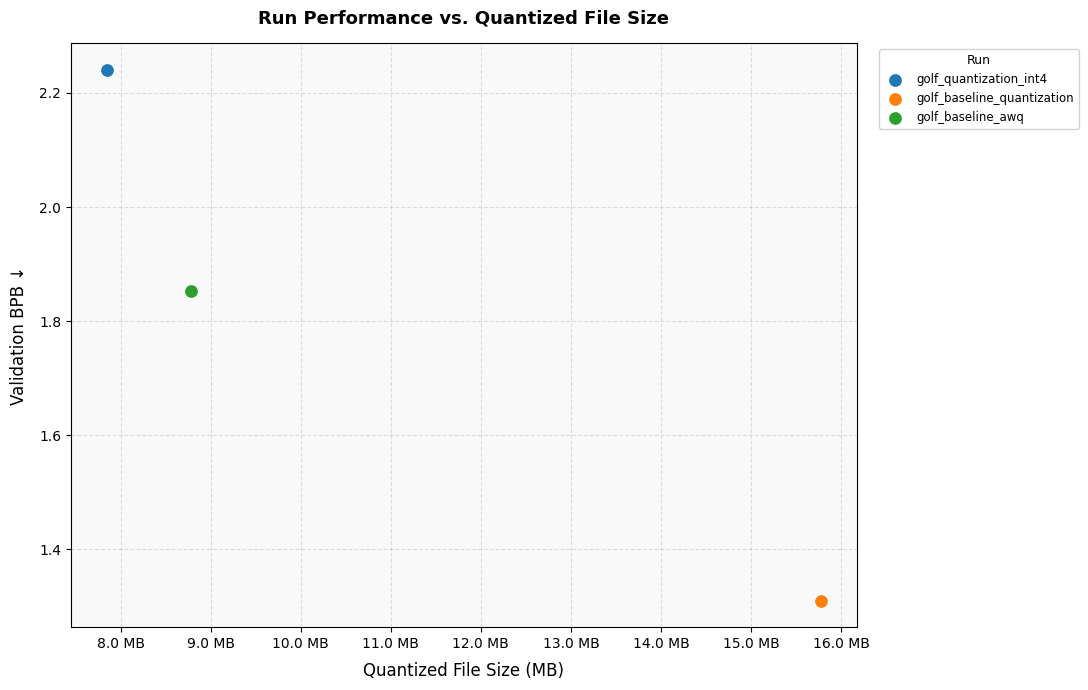

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Start from your filtered dataframe
df_plot = df_filtered.copy()

# Ensure numeric columns are numeric
df_plot["final_val_bpb"] = pd.to_numeric(df_plot["final_val_bpb"], errors="coerce")
df_plot["quant_file_bytes"] = pd.to_numeric(df_plot["quant_file_bytes"], errors="coerce")

# Drop rows with missing metric values
df_plot = df_plot.dropna(subset=["final_val_bpb", "quant_file_bytes"])

# Each model/run setting is represented by 3 consecutive rows
df_plot["run_group"] = np.arange(len(df_plot)) // 3

# Compute means across each group of 3 rows
df_mean = (
    df_plot
    .groupby("run_group", as_index=False)
    .agg(
        run_name=("run_name", "first"),
        final_val_bpb=("final_val_bpb", "mean"),
        quant_file_bytes=("quant_file_bytes", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(11, 7))

# Plot each averaged run group individually so legend labels work
for _, row in df_mean.iterrows():
    ax.scatter(
        row["quant_file_bytes"] / 1e6,
        row["final_val_bpb"],
        s=100,
        edgecolors="white",
        linewidths=0.8,
        zorder=3,
        label=row["run_name"],
    )

ax.legend(
    title="Run",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8.5,
    title_fontsize=9,
    framealpha=0.9,
)

ax.set_xlabel("Quantized File Size (MB)", fontsize=12, labelpad=8)
ax.set_ylabel("Validation BPB ↓", fontsize=12, labelpad=8)
ax.set_title("Run Performance vs. Quantized File Size", fontsize=13, fontweight="bold", pad=14)

ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f MB"))

plt.tight_layout()
plt.savefig("run_size_vs_bpb.png", dpi=150, bbox_inches="tight")
plt.show()

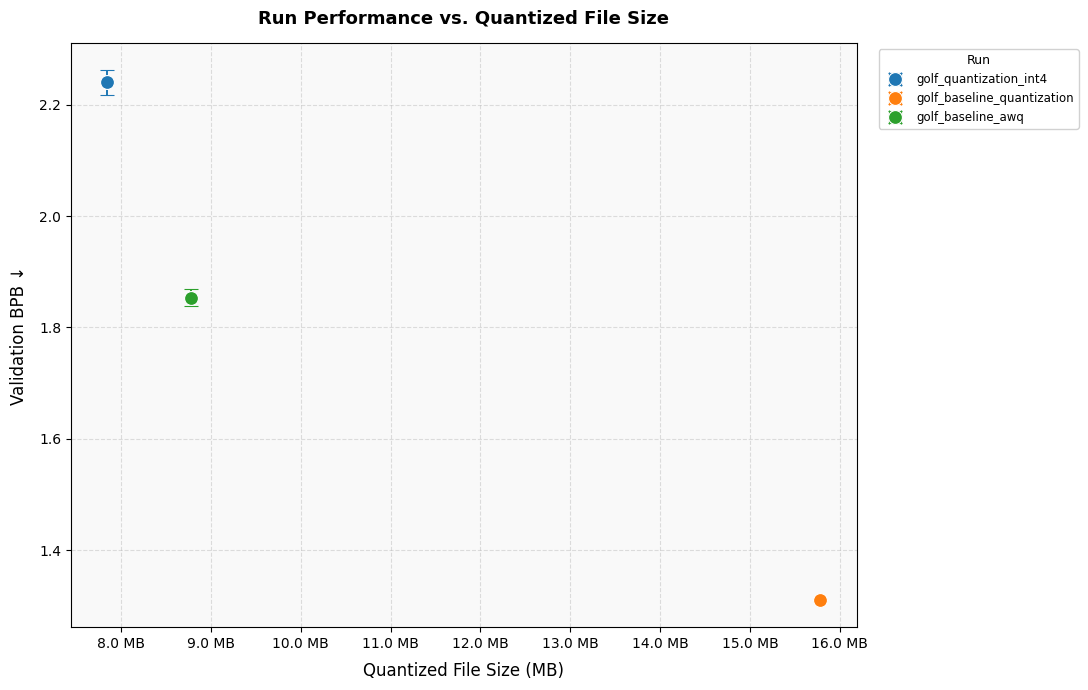

In [23]:

# Make a copy
df_plot = df_filtered.copy()

# Ensure numeric columns are numeric
df_plot["final_val_bpb"] = pd.to_numeric(df_plot["final_val_bpb"], errors="coerce")
df_plot["quant_file_bytes"] = pd.to_numeric(df_plot["quant_file_bytes"], errors="coerce")

# Drop rows with missing values in the relevant columns
df_plot = df_plot.dropna(subset=["final_val_bpb", "quant_file_bytes"])

# Each run is made of 3 consecutive rows
df_plot["run_group"] = np.arange(len(df_plot)) // 3

# Compute mean and variance for each group
df_stats = (
    df_plot
    .groupby("run_group")
    .agg(
        run_name=("run_name", "first"),
        final_val_bpb=("final_val_bpb", "mean"),
        final_val_bpb_var=("final_val_bpb", "var"),
        quant_file_bytes=("quant_file_bytes", "mean"),
        quant_file_bytes_var=("quant_file_bytes", "var"),
    )
    .reset_index()
)

# Optional: replace NaN variances with 0 in case a group has only one row
df_stats["final_val_bpb_var"] = df_stats["final_val_bpb_var"].fillna(0)
df_stats["quant_file_bytes_var"] = df_stats["quant_file_bytes_var"].fillna(0)

fig, ax = plt.subplots(figsize=(11, 7))

for _, row in df_stats.iterrows():
    x = row["quant_file_bytes"] / 1e6
    y = row["final_val_bpb"]

    xerr = np.sqrt(row["quant_file_bytes_var"]) / 1e6
    yerr = np.sqrt(row["final_val_bpb_var"])

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        markersize=10,
        capsize=5,
        elinewidth=1.4,
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=3,
        label=row["run_name"],
    )

ax.legend(
    title="Run",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8.5,
    title_fontsize=9,
    framealpha=0.9,
)

ax.set_xlabel("Quantized File Size (MB)", fontsize=12, labelpad=8)
ax.set_ylabel("Validation BPB ↓", fontsize=12, labelpad=8)
ax.set_title("Run Performance vs. Quantized File Size", fontsize=13, fontweight="bold", pad=14)

ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f MB"))

plt.tight_layout()
plt.savefig("run_size_vs_bpb_with_variance.png", dpi=150, bbox_inches="tight")
plt.show()

### Clearly the baseline performs the best out of the models but it also has the highest file size. We see the real ability of AWQ when compared to the int4 model as the models share similar file bytes (AWQ has only few percent of the weights not in int4 but in fp16) and  AWQ clearly outperforms it